# Project interactive visualization
Using a dataset that your group is consider using for the term project, let's build some meaningful user-driven data visualization. Depending on your dataset this could include:
- Usage of geospatial information
- Building interactive views with widgets
- Organize multiple components into a simple dashboard

Keep these design principles in mind:
While you navigate through this notebook some things to take into consideration:
* Do not add interaction just to add it. Make sure it helps answer a question.
* Use meaningful titles and labels
* Document your code so it's readable and clean. If something does not work, document the issue and explain your best attempt.

In [2]:
## These are most likely the libraries you will use
# Add or remove imports as needed

import pandas as pd
import numpy as np

# Visualization libraries
import plotly.express as px
import plotly.graph_objects as go

# Geospatial / geocoding
from geopy.geocoders import Nominatim

# Panel
import panel as pn
pn.extension('plotly')

In [3]:
### Load your dataset here

# Example:
# df = pd.read_csv("your_dataset.csv")
df=pd.read_csv("/Users/nt97/Documents/SJSU/Spring 2026/CS133/Dataset for Project/sdud2025.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999999 entries, 0 to 999998
Data columns (total 15 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Utilization Type                999999 non-null  object 
 1   State                           999999 non-null  object 
 2   NDC                             999999 non-null  int64  
 3   Labeler Code                    999999 non-null  int64  
 4   Product Code                    999999 non-null  int64  
 5   Package Size                    999999 non-null  int64  
 6   Year                            999999 non-null  int64  
 7   Quarter                         999999 non-null  int64  
 8   Suppression Used                999999 non-null  bool   
 9   Product Name                    999999 non-null  object 
 10  Units Reimbursed                484560 non-null  float64
 11  Number of Prescriptions         484560 non-null  float64
 12  Total Amount Rei

In [5]:
# Write your code here
df.describe()

,NDC,Labeler Code,Product Code,Package Size,Year,Quarter,Units Reimbursed,Number of Prescriptions,Total Amount Reimbursed,Medicaid Amount Reimbursed,Non Medicaid Amount Reimbursed
count,9.999990e+05,999999.000000,999999.000000,999999.000000,999999.0,999999.000000,4.845600e+05,484560.000000,4.845600e+05,4.845600e+05,4.845600e+05
mean,4.153890e+10,41538.771279,1264.236110,21.536382,2025.0,1.508503,1.974853e+04,302.700658,4.741485e+04,4.543607e+04,1.978782e+03
std,2.789693e+10,27897.032749,2081.267732,27.356980,0.0,0.499928,2.419736e+05,1709.229929,6.598699e+05,6.480829e+05,3.374071e+04
min,2.015201e+06,2.000000,0.000000,0.000000,2025.0,1.000000,1.700000e-02,11.000000,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.366801e+10,13668.000000,179.000000,1.000000,2025.0,1.000000,6.900000e+02,21.000000,3.706300e+02,3.469200e+02,0.000000e+00
50%,5.166008e+10,51660.000000,469.000000,10.000000,2025.0,2.000000,2.020000e+03,50.000000,1.207125e+03,1.118430e+03,0.000000e+00
75%,6.787703e+10,67877.000000,923.000000,30.000000,2025.0,2.000000,7.409000e+03,160.000000,5.386077e+03,4.929470e+03,3.000000e+01
max,1.000000e+11,99999.000000,9999.000000,99.000000,2025.0,2.000000,6.091285e+07,224386.000000,1.196075e+08,1.159903e+08,1.040087e+07


In [6]:
df['State'].value_counts()

State
CA    80110
KY    73990
MA    72861
IL    66793
IN    64723
GA    63268
FL    62779
LA    55080
CO    49795
AZ    48750
AR    46031
IA    45853
DC    40618
CT    35740
AL    34313
KS    32558
DE    30700
ID    27860
HI    23727
MD    23411
AK    21039
Name: count, dtype: int64

## Question 1: Analytical Question
Write a question about your data that can be explored with an interactive plot. A good example would be a question where you can compare different categories. Explain how the plot help answer your question and why you choose that plot type.

Examples:
- Which regions have the highest average values?
- How does one variable compare across time?

Analytical Question: How does total reimbursement in dollars vary for GLP-1 and non GLP-1 drugs across the 21 states in the US?

## Question 2. Create a simple interaction plot
Create a plot, it can be related to your question #1 or a new question, that users can interact with in some meaningful way. Explain in a markdown, how does the interaction add to the analysis.

Example of possible interactions:
*   Hover over information
*   Toogle between groups

In [10]:
# Your code . . .
df["Product Name"] = df["Product Name"].str.strip()
 
GLP1_DRUGS = [
    "OZEMPIC", "WEGOVY", "MOUNJARO", "ZEPBOUND", "TRULICITY",
    "BYETTA", "RYBELSUS", "SAXENDA", "VICTOZA", "BYDUREON",
    "EXENATIDE", "LIRAGLUTID",
]
 
def classify(name):
    if not isinstance(name, str):
        return "Non-GLP-1"
    for g in GLP1_DRUGS:
        if name.upper().startswith(g):
            return "GLP-1"
    return "Non-GLP-1"
 
def base_drug(name):
    if not isinstance(name, str):
        return "OTHER"
    for g in GLP1_DRUGS:
        if name.upper().startswith(g):
            return g
    return "OTHER"
 
df["Category"]  = df["Product Name"].apply(classify)
df["Drug"]      = df["Product Name"].apply(base_drug)
 
agg = (
    df.groupby(["State", "Category"])
    .agg(
        Total_Reimbursed   = ("Total Amount Reimbursed",   "sum"),
        Num_Prescriptions  = ("Number of Prescriptions",   "sum"),
    )
    .reset_index()
)
 
pivot = agg.pivot(index="State", columns="Category",
                  values=["Total_Reimbursed", "Num_Prescriptions"]).fillna(0)
pivot.columns = ["_".join(c) for c in pivot.columns]
pivot = pivot.reset_index()
 
pivot["Total_Spend"]      = pivot["Total_Reimbursed_GLP-1"] + pivot["Total_Reimbursed_Non-GLP-1"]
pivot["GLP1_Share_Pct"]   = pivot["Total_Reimbursed_GLP-1"] / pivot["Total_Spend"] * 100
pivot["GLP1_PerRx"]       = (
    pivot["Total_Reimbursed_GLP-1"] /
    pivot["Num_Prescriptions_GLP-1"].replace(0, float("nan"))
)
pivot["NonGLP1_PerRx"]    = (
    pivot["Total_Reimbursed_Non-GLP-1"] /
    pivot["Num_Prescriptions_Non-GLP-1"].replace(0, float("nan"))
)
 
drug_agg = (
    df[df["Category"] == "GLP-1"]
    .groupby(["State", "Drug"])
    .agg(Total=("Total Amount Reimbursed", "sum"),
         Rx   =("Number of Prescriptions", "sum"))
    .reset_index()
)
 
DRUG_COLORS = {
    "OZEMPIC":    "#00d4ff",
    "WEGOVY":     "#a78bfa",
    "MOUNJARO":   "#ffd166",
    "ZEPBOUND":   "#ff6b6b",
    "TRULICITY":  "#06d6a0",
    "RYBELSUS":   "#f97316",
    "SAXENDA":    "#ec4899",
    "VICTOZA":    "#94a3b8",
    "BYETTA":     "#84cc16",
    "LIRAGLUTID": "#14b8a6",
    "BYDUREON":   "#78716c",
    "EXENATIDE":  "#64748b",
}

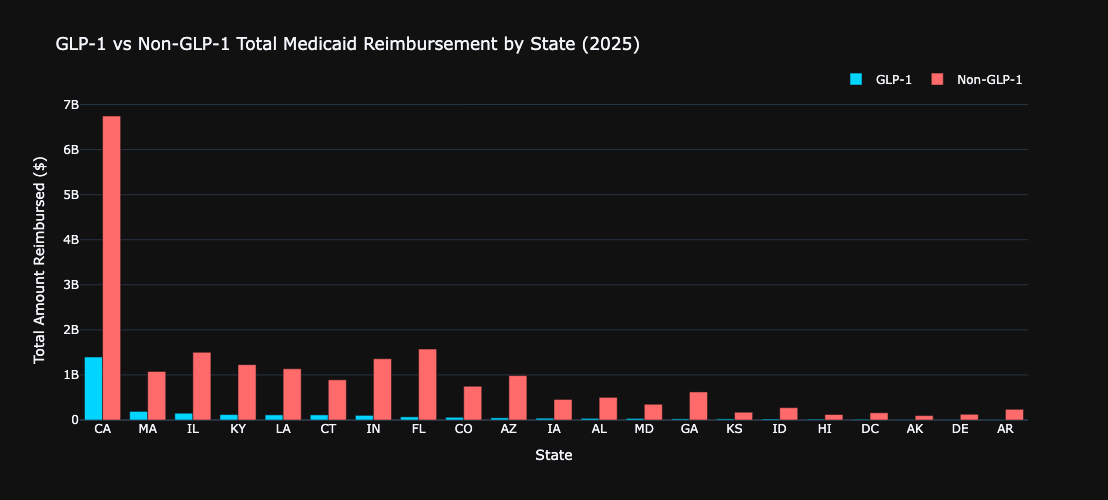

In [11]:
p1 = pivot.sort_values("Total_Reimbursed_GLP-1", ascending=False)
 
fig1 = go.Figure()
fig1.add_trace(go.Bar(
    name="GLP-1",
    x=p1["State"],
    y=p1["Total_Reimbursed_GLP-1"],
    marker_color="#00d4ff",
    customdata=p1[["Num_Prescriptions_GLP-1", "GLP1_Share_Pct"]],
    hovertemplate=(
        "<b>%{x}</b><br>"
        "GLP-1 Reimbursed: $%{y:,.0f}<br>"
        "Rx Count: %{customdata[0]:,.0f}<br>"
        "GLP-1 Share: %{customdata[1]:.1f}%"
        "<extra></extra>"
    ),
))
fig1.add_trace(go.Bar(
    name="Non-GLP-1",
    x=p1["State"],
    y=p1["Total_Reimbursed_Non-GLP-1"],
    marker_color="#ff6b6b",
    customdata=p1[["Num_Prescriptions_Non-GLP-1"]],
    hovertemplate=(
        "<b>%{x}</b><br>"
        "Non-GLP-1 Reimbursed: $%{y:,.0f}<br>"
        "Rx Count: %{customdata[0]:,.0f}"
        "<extra></extra>"
    ),
))
fig1.update_layout(
    title="GLP-1 vs Non-GLP-1 Total Medicaid Reimbursement by State (2025)",
    xaxis_title="State",
    yaxis_title="Total Amount Reimbursed ($)",
    barmode="group",
    template="plotly_dark",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    height=500,
)
fig1.show()

## Question 3. Choropleth Planning
Design a choropleth idea using your dataset.
In a markdown cell:
*  Identify the geographic unit you would map (state, county, country, ZIP code, etc.)
*  Identify the variable you would color by
*  Explain if any aggregation or preprocessing is needed
*  Briefly describe what GeoJSON file would be required

You do not need to have a perfect dataset for this question. However, your plan should be realistic.

If your data does not fully support a choropleth, build a prototype table that explains that structure you would need before mapping.

Geographic Unit: State
Variable to color by: `Total_Reimbursed_GLP-1` from the 'pivot' table
Aggregation/ Preprocessing: is not needed since the pivot table  already has one row per state with both reimbursement totals ready to use.
GeoJSON: None


## Question 4. Geospatial Possibility Check

Determine whether your dataset can support a map-based visualization.

In a markdown cell, answer one of the following:
- If **yes**, explain what geographic fields you have and what type of map is appropriate.
- If **no**, explain what is missing and what you would need to create a map.

Write code that inspects or prepares the geographic column(s) you may use.

Yes, the 'State' column in the df can be used to map directly by plotly built in states. 

In [ ]:
# Your code . . .
print("Columns:", df.columns.tolist())
print()
print("State column sample:")
print(df["State"].dropna().unique()[:20])
print(f"\nTotal unique states/territories: {df['State'].nunique()}")
print(f"Missing State values: {df['State'].isna().sum()}")

## Question 5. Geopy / Location Preparation

If your dataset has location names, addresses, cities, states, or countries, use geopy on a sample of your data to geocode locations or validate location information.

If your dataset does not have data that contains location, pick 5 destination you want to visit and use geopy to geocode locations.

In [12]:
# Your code . . .
from geopy.geocoders import Nominatim
import time

geolocator = Nominatim(user_agent="cs133_p3")

sample_states = df["State"].dropna().unique()[:5]

state_coords = []

for state in sample_states:
    location = geolocator.geocode(f"{state}, USA")
    if location:
        state_coords.append({
            "State": state,
            "Lat": location.latitude,
            "Lon": location.longitude
        })
        print(f"{state}: ({location.latitude:.4f}, {location.longitude:.4f})")
    time.sleep(1)

coords_df = pd.DataFrame(state_coords)
print()
print(coords_df)

AK: (64.4460, -149.6809)
AL: (33.2589, -86.8295)
AR: (35.2049, -92.4479)
AZ: (34.3953, -111.7633)
CA: (36.7015, -118.7560)

  State        Lat         Lon
0    AK  64.445961 -149.680909
1    AL  33.258882  -86.829534
2    AR  35.204888  -92.447911
3    AZ  34.395342 -111.763275
4    CA  36.701463 -118.755997


## Question 6. Panel Widget

Create a Panel Widget that controls something in your analysis such as the ability to choose a column, category, year, etc.

The widget should affect an output such as a plot, table, or summary statistic.

In [ ]:
# Your code . . .
import panel as pn
pn.extension('plotly')

metric_select = pn.widgets.Select(
    name="Metric",
    options={
        "GLP-1 Total Reimbursed ($)":     "Total_Reimbursed_GLP-1",
        "Non-GLP-1 Total Reimbursed ($)": "Total_Reimbursed_Non-GLP-1",
        "GLP-1 Prescription Count":       "Num_Prescriptions_GLP-1",
        "GLP-1 Share of Total Spend (%)": "GLP1_Share_Pct",
    },
    value="Total_Reimbursed_GLP-1",
)

@pn.depends(metric_select)
def update_chart(metric):
    label = [k for k, v in metric_select.options.items() if v == metric][0]
    data = pivot.nlargest(20, metric)
    fig = px.bar(
        data, x="State", y=metric,
        color=metric, color_continuous_scale="Viridis",
        title=f"Top 20 States by {label}",
        labels={metric: label},
        template="plotly_dark",
        height=450,
    )
    fig.update_layout(coloraxis_showscale=False)
    return pn.pane.Plotly(fig)

dashboard = pn.Column(
    "## GLP-1 Medicaid Metrics Explorer",
    metric_select,
    update_chart,
)
dashboard.servable()
dashboard

## Question 7. Mini Dashboard

Build a small Panel dashboard with at least two components. Arrange the components so that it is in a readable layout. Your dashboard should include:
* At least one plot,
* An additional element of your choice such as a widget, table, second plot, etc.

In [13]:
# Write your code here
import panel as pn
pn.extension('plotly')

fig_map = go.Figure(go.Choropleth(
    locations=pivot["State"],
    z=pivot["Total_Reimbursed_GLP-1"],
    locationmode="USA-states",
    colorscale="Plasma",
    colorbar_title="Reimbursed ($)",
    hovertemplate="<b>%{location}</b><br>GLP-1 Reimbursed: $%{z:,.0f}<extra></extra>",
))
fig_map.update_layout(
    title_text="GLP-1 Total Medicaid Reimbursement by State (2025)",
    geo_scope="usa",
    template="plotly_dark",
    height=420,
    margin=dict(l=0, r=0, t=50, b=0),
)

top10_states = pivot.nlargest(10, "Total_Reimbursed_GLP-1")["State"].tolist()
df_top10 = pivot[pivot["State"].isin(top10_states)].sort_values("Total_Reimbursed_GLP-1", ascending=False)

fig_bar = go.Figure()
fig_bar.add_trace(go.Bar(
    name="GLP-1",
    x=df_top10["State"],
    y=df_top10["Total_Reimbursed_GLP-1"],
    marker_color="#00d4ff",
))
fig_bar.add_trace(go.Bar(
    name="Non-GLP-1",
    x=df_top10["State"],
    y=df_top10["Total_Reimbursed_Non-GLP-1"],
    marker_color="#ff6b6b",
))
fig_bar.update_layout(
    title="GLP-1 vs Non-GLP-1 Reimbursement – Top 10 States",
    xaxis_title="State",
    yaxis_title="Total Amount Reimbursed ($)",
    barmode="group",
    template="plotly_dark",
    height=420,
)

dashboard = pn.Column(
    "# GLP-1 Medicaid Spending Dashboard (2025)",
    pn.Row(
        pn.pane.Plotly(fig_map, sizing_mode="stretch_width"),
        pn.pane.Plotly(fig_bar, sizing_mode="stretch_width"),
    ),
)
dashboard.servable()
dashboard

Column
    [0] Markdown(str)
    [1] Row
        [0] Plotly(Figure, sizing_mode='stretch_width')
        [1] Plotly(Figure, sizing_mode='stretch_width')

## Question 8. Reflection

Write a short reflection addressing all of the following:
- Which interactive element was most useful in your notebook?
- What was the hardest part of working with your dataset?
- Did implementing interactive tools help your analysis? Why or why not?
- If you had more time, what would you improve or add?

# Write your code here
The interactive element I felt most useful is the ability to zoom in and visualize obscure differences that are rather hard to notice with the regular view. Secondly, the choropleth map was also useful due to heat map like visuals that clearly and instantly tell the story.
The hardest part was preprocessing the data. Classifying product names into GLP-1 vs Non-GLP-1 categories were somewhat tedious since the names were inconsistently formatted, and then pivoting the table into a structure that was actually usable for plotting.
Yes, interactive tools build a more informed dashboard with features, informations in one move of a mouse, allowing for an efficient exploration of the data. 
I believe I would add a time-series component to analyze how GLP-1 spending has grown over the years and dive deep down into a granular geographical location such as a county within a state. 